In [1]:
##prepare environment
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pickle
from math import trunc

sourceDirectory = '../delfic_test/'

#build a list of all the folders in the source directory
import os
falloutFields = [f for f in os.listdir(sourceDirectory) if os.path.isdir(os.path.join(sourceDirectory, f))]

def uniform_sample_ellipse(a, b, theta, num_points):
    """
    Uniformly sample points from an ellipse.
    
    Parameters:
    a (float): Semi-major axis
    b (float): Semi-minor axis
    theta (float): Rotation angle of the ellipse (in radians)
    num_points (int): Number of points to sample
    
    Returns:
    np.ndarray: Sampled points (num_points, 2)
    """
    # Generate uniform points in a unit circle
    angles = np.random.uniform(0, 2 * np.pi, num_points)
    radii = np.sqrt(np.random.uniform(0, 1, num_points))
    
    # Convert to Cartesian coordinates
    x_unit = radii * np.cos(angles)
    y_unit = radii * np.sin(angles)
    
    # Scale points to the ellipse
    x_ellipse = a * x_unit
    y_ellipse = b * y_unit
    
    # Rotate points by theta
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    
    x_rot = cos_theta * x_ellipse - sin_theta * y_ellipse
    y_rot = sin_theta * x_ellipse + cos_theta * y_ellipse
    
    # Combine and return
    return np.vstack((x_rot, y_rot)).T

In [2]:
##open the pickle file, and return the data and prodominant fallout direction
def getFieldData(falloutField):
  with open(sourceDirectory + falloutField + f'/{falloutField}.pkl', 'rb') as f:
    #data is an np.array of shape (timestep, x, y)
    data = pickle.load(f)
  
  #use only a subsection of the first time step to determine the direction
  truncDataScale = 50
  truncDataLowerLimit = data.shape[1]//2 - truncDataScale//2 
  truncData = data[0,truncDataLowerLimit:truncDataLowerLimit+truncDataScale, truncDataLowerLimit:truncDataLowerLimit+truncDataScale]

  # Define a threshold for significant traffic
  minThreshold = 0.1 * np.max(truncData)
  maxThreshold = 0.9 * np.max(truncData)
  # apply the min and max threshold
  falloutIndices = np.nonzero((truncData > minThreshold) & (truncData < maxThreshold))
  falloutX = np.array(falloutIndices[1])
  falloutY = np.array(falloutIndices[0])
  weights = truncData[falloutY, falloutX]  # Use exposure data as weights

  # Calculate the center of the grid
  truncCenterX = (truncData.shape[1] - 1) / 2
  truncCenterY = (truncData.shape[0] - 1) / 2

  # Convert to polar coordinates relative to the center
  angles = np.arctan2(falloutY - truncCenterY, falloutX - truncCenterX)

  # Compute the weighted average angle
  falloutDir = np.arctan2(np.sum(np.sin(angles) * weights), np.sum(np.cos(angles) * weights))

  return data, falloutDir


In [3]:
##plot the fallout field
cmap = plt.cm.jet
cmaplist = [cmap(i) for i in range(cmap.N)]
cmaplist[0] = (1, 1, 1, 1.0)
cmap = mcolors.LinearSegmentedColormap.from_list('Custom cmap', cmaplist, cmap.N)

##plotting function
def plotField(radfield, falloutDirection, pixelScale=1, gridScale=1, visibleRadius=None, plotCenter=None) -> plt.Figure:
  #scale provides the units per pixel
  #visibleRadius provides the radius of the visible area in km
  # if visibleRadius is None, the entire field is shown
  plt.figure(figsize=(10, 10))
  ax = plt.gca()
  fig = plt.gcf()
  extent = (0, radfield.shape[1]*pixelScale, 0, radfield.shape[0]*pixelScale)
  im = ax.imshow(radfield, origin='lower', cmap=cmap, alpha=0.5, extent=extent)
  colorbar = fig.colorbar(im, ax=ax, orientation='vertical')
  colorbar.set_label('Color Intensity')

  # Create a line that originates from the center of the field and extends 
  # along the angle provided by the falloutDirection parameter [radians]
  center = np.array(radfield.shape) / 2 * pixelScale
  radius = min(center) * .8
  end = center + radius * np.array([np.sin(falloutDirection), np.cos(falloutDirection)])
  ax.plot([center[1], end[1]], [center[0], end[0]], 'r-')

  # add a 1km square grid to the plot, 10 units per km
  ax.grid(which='both', color='black', linestyle='-', linewidth=0.5)
  ax.set_xticks(np.arange(0, radfield.shape[1]*pixelScale, gridScale))
  ax.set_yticks(np.arange(0, radfield.shape[0]*pixelScale, gridScale))

  if plotCenter is None:
    plotCenter = center
  else:
    plotCenter = np.array([plotCenter[1], plotCenter[0]])

  # set the visible area of the plot
  if visibleRadius is not None:
    ax.set_xlim(plotCenter[1] - visibleRadius, plotCenter[1] + visibleRadius)
    ax.set_ylim(plotCenter[0] - visibleRadius, plotCenter[0] + visibleRadius)

  return fig

In [4]:
##plot the gate locations
def plotGateways(fig, gateways, detFieldCenter=None, params=None):
  ax = fig.gca()
  for gateway in gateways:
    ax.plot(gateway[0], gateway[1], 'kx')

  if detFieldCenter is not None and params is not None:
    #plot two black circles to represent the gateway limits about the center
    ax.add_artist(plt.Circle(detFieldCenter, params['GatewayMinRange'], color='black', fill=False))
    ax.add_artist(plt.Circle(detFieldCenter, params['GatewayMaxRange'], color='black', fill=False))
     

  return fig

In [5]:
##plot the detector field
def plotDetectors(fig, detectors, artyDir=None):
  ax = fig.gca()
  for detector in detectors:
    ax.plot(detector[0], detector[1], 'k+')

  if artyDir is not None:
    #create a quiver plot to show the direction of the incoming artillery
    #it should be 2km from the first detector and 1km long
    artyStart = detectors[0]
    artyStart = artyStart + 2 * np.array([np.cos(artyDir), np.sin(artyDir)])
    artyEnd = artyStart + 1 * np.array([np.cos(artyDir), np.sin(artyDir)])

    ax.quiver(artyStart[0], artyStart[1], artyEnd[0] - artyStart[0], artyEnd[1] - artyStart[1], angles='xy', scale_units='xy', scale=1)

  return fig

In [6]:
##generate the detector field
def genDetectorField(falloutfield, pixelScale, falloutDir, params, distFromGZ):
  gatewayLocations = []
  detectorLocations = []

  #determine the location of ground zero in km
  gzLocation = np.array(falloutfield[0].shape) / 2 * pixelScale

  #determine the center location of the detector field
  detFieldCenter = gzLocation + np.array([np.cos(falloutDir), np.sin(falloutDir)]) * distFromGZ

  # Define the gateway locations
  for _ in range(params['nGateways']):
    while True:
      gatewayDist = np.random.uniform(params['GatewayMinRange'], params['GatewayMaxRange'])
      gatewayAngle = np.random.uniform(0, 2 * np.pi)
      loc = np.array([np.sin(gatewayAngle), np.cos(gatewayAngle)]) * gatewayDist + detFieldCenter

      #check if the exposure rate at the gateway location is above the threshold
      if falloutfield[0][trunc(loc[1]/pixelScale), trunc(loc[0]/pixelScale)] < params['GatewayMaxExposure']:
        gatewayLocations.append(loc)
        break

  # Determine the arty firing point
  artyFP_distances = np.random.uniform(params['ArtyMinRange'], params['ArtyMaxRange'])
  artyFP_angle = np.random.uniform(0, 2 * np.pi)
  artyFP = np.array([np.cos(artyFP_angle), np.sin(artyFP_angle)]) * artyFP_distances + detFieldCenter
  artyDir = detFieldCenter - artyFP
  artyDir = np.arctan2(artyDir[0], artyDir[1])

  # Determine the arty shell locations
  artyLocations = uniform_sample_ellipse(params['ArtyFieldWidth'], 
                                         params['ArtyFieldDepth'], 
                                         falloutDir+np.radians(params['ArtyFieldRotation']), 
                                         params['nArtyShells'])
  artyLocations += detFieldCenter

  # Determine the detector locations
  for shellLoc in artyLocations:
    detLocations = uniform_sample_ellipse(params['DetDispersionLength'], 
                                          params['DetDispersionWidth'], 
                                          artyDir, 
                                          params['nDetPerShell'])
    detLocations += shellLoc
    detectorLocations.extend(detLocations)

  return detectorLocations, gatewayLocations, detFieldCenter, artyDir

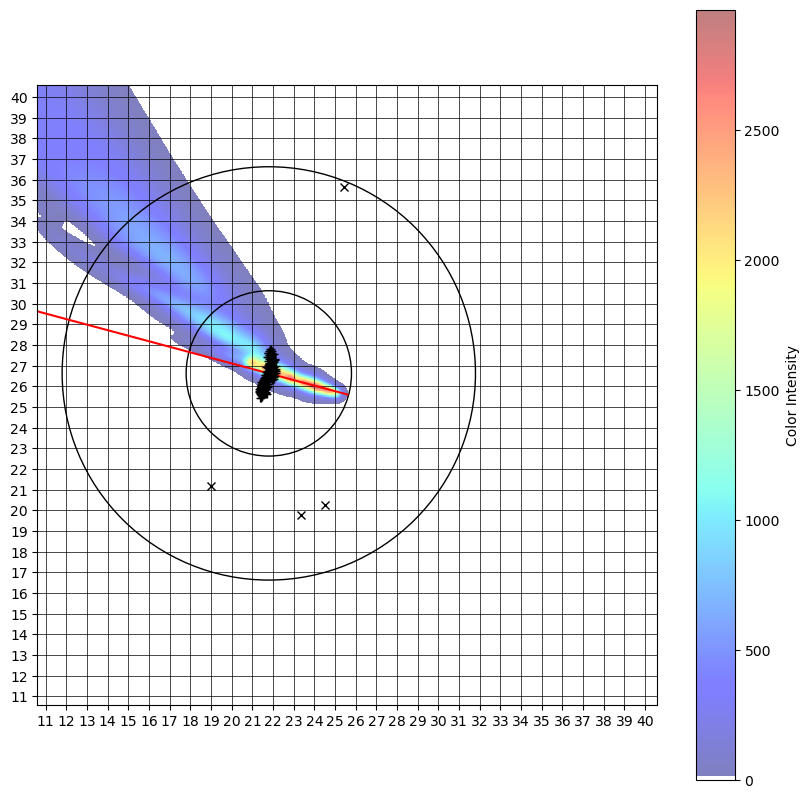

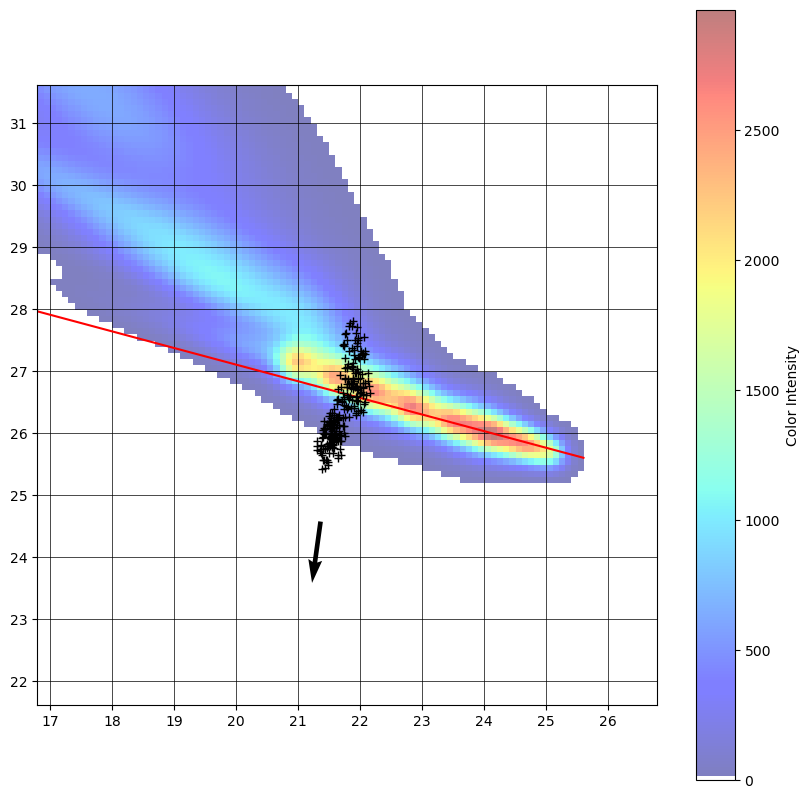

In [7]:
##generate a sample field and plot it
randIndex = np.random.randint(0, len(falloutFields))
falloutfield, falloutDir = getFieldData(falloutFields[randIndex])

fig = plotField(radfield=falloutfield[0], falloutDirection=falloutDir, pixelScale=.1, visibleRadius=15)

SCARM_Parameters = {'nArtyShells'        : 10, # number of artillery shells
                    'ArtyMinRange'       : 15, # minimum range of artillery [km]
                    'ArtyMaxRange'       : 40, # maximum range of artillery [km]
                    'ArtyFieldWidth'     :1.5, # width of the artillery field [km]
                    'ArtyFieldDepth'     : .2, # length of the artillery field [km]
                    'ArtyFieldRotation'  : 90, # angle of the artillery field from the fallout direction [degrees]
                    'nDetPerShell'       : 24, # number of detectors per shell
                    'DetDispersionWidth' : .2, # width of the detector dispersion [km]
                    'DetDispersionLength': .4, # length of the detector dispersion [km]
                    'nGateways'          :  4, # number of gateways
                    'GatewayMaxRange'    : 10, # maximum range of gateways [km]
                    'GatewayMinRange'    :  4, # minimum range of gateways [km]
                    'GatewayMaxExposure' : 50, # maximum exposure of gateways locations
                    'GatewayMinSeparation': 2, # minimum separation between gateways [km]
                    }

minDistFromGZ = 2  # minimum distance from ground zero [km]
maxDistFromGZ = 10 # maximum distance from ground zero [km]
distFromGZ = np.random.uniform(minDistFromGZ, maxDistFromGZ)

detectorLocations, gatewayLocations, detFieldCenter, artyDir = genDetectorField(falloutfield, .1, falloutDir, SCARM_Parameters, distFromGZ)
fig = plotGateways(fig, gatewayLocations, detFieldCenter=detFieldCenter, params=SCARM_Parameters)
fig = plotDetectors(fig, detectorLocations)
plt.show()

fig = plotField(radfield=falloutfield[0], falloutDirection=falloutDir, pixelScale=.1, visibleRadius=5, plotCenter=detFieldCenter)
fig = plotDetectors(fig, detectorLocations, artyDir)
plt.show()


In [8]:
##fit exponential functions to each pixel of relavance
from math import exp
from scipy.optimize import curve_fit

##determine the pixels that the detectors are in
def getDetectorPixels(detectorLocations, pixelScale):
  detectorPixels = set()
  for detector in detectorLocations:
    #determine the 4 surrounding pixels
    x = trunc(detector[0]/pixelScale)
    y = trunc(detector[1]/pixelScale)

    detectorPixels.add((x, y))
    detectorPixels.add((x+1, y))
    detectorPixels.add((x, y+1))
    detectorPixels.add((x+1, y+1))

  return list(detectorPixels)

def doubleExponential(t, a, b, c, d):
  return a * np.exp(-b * t) + c * np.exp(-d * t)
  
def getExpFitParams(data, detectorLocations, pixelScale):
  pixels = getDetectorPixels(detectorLocations, pixelScale)

  #fit the exponential function to a representative pixel
  x = np.arange(0, data.shape[0], 1)
  y = data[:, pixels[0][1], pixels[0][0]]

  popt, pcov = curve_fit(doubleExponential, x, y, p0=[1, 1, 1, 1])

  ##fit the exponential function to all the pixels
  fitExpParams = {}
  x = np.arange(0, data.shape[0], 1)
  cutoff = 10
  for pixel in pixels:
    y = data[:, pixel[1], pixel[0]]
    if np.max(y) < cutoff:
      continue
    try:
      popt, pcov = curve_fit(doubleExponential, x, y, p0=[1, 1, 1, 1])
      fitExpParams[pixel] = popt
    except:
      pass

  return fitExpParams

In [9]:
##for each detector, determine the exposure rate at all times using interpolation
def getDetectorExposure(detectorLocations, fieldExpParams, pixelScale, timesteps):
  detectorExposure = np.zeros((len(timesteps), len(detectorLocations)))
  for d, detector in enumerate(detectorLocations):
    x = trunc(detector[0]/pixelScale)
    y = trunc(detector[1]/pixelScale)

    surroundingPixels = [(x, y), (x+1, y), (x, y+1), (x+1, y+1)] #the 4 surrounding pixels

    for t, timestep in enumerate(timesteps):
      knownExposureRates = np.zeros(4) #exposure rates for the 4 surrounding pixels
      for p, pixel in enumerate(surroundingPixels):
        if pixel in fieldExpParams:
          knownExposureRates[p] = doubleExponential(timestep, *fieldExpParams[pixel])

      #interpolate the exposure rate
      x0 = x * pixelScale
      y0 = y * pixelScale
      x1 = x0 + pixelScale
      y1 = y0 + pixelScale

      _x = detector[0]
      _y = detector[1]

      #interpolate the exposure rate
      detectorExposure[t, d] = ((x1 - _x) * (y1 - _y) * knownExposureRates[0] +
                                (_x - x0) * (y1 - _y) * knownExposureRates[1] +
                                (x1 - _x) * (_y - y0) * knownExposureRates[2] +
                                (_x - x0) * (_y - y0) * knownExposureRates[3]) / (pixelScale**2)
  return detectorExposure

nTimesteps = 100
timesteps = np.linspace(0, falloutfield.shape[0], nTimesteps)
fitExpParams = getExpFitParams(falloutfield, detectorLocations, .1)
detectorExposures = getDetectorExposure(detectorLocations, fitExpParams, .1, timesteps)


/tmp/ipykernel_1463708/3094044384.py:21: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * t) + c * np.exp(-d * t)
/tmp/ipykernel_1463708/3094044384.py:21: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(-b * t) + c * np.exp(-d * t)


In [10]:
##for each detector, determine the predicted location for each timestep
from simSCRAM_detector import SimDetector
from SCRAM_field import Gateway

gateways = []
for g, gateway in enumerate(gatewayLocations):
  gateways.append(Gateway(gateway[0], gateway[1], g))

detectorField = []
for d, detector in enumerate(detectorLocations):
  detectorField.append(SimDetector(detector[0], detector[1], 
                                   detectorExposures[:, d], d, gateways,
                                   timesteps))

from multiprocessing import Pool
#wrapper function to process each detector for each timestep in parallel
def processDetector(detector):
  detector.mp()
  return detector

with Pool(128) as p:
  detectorField = p.map(processDetector, detectorField)


/home/dave/SCRAM/DELFIC_processing/SCRAM_field.py:85: RuntimeWarning: invalid value encountered in sqrt
  self.estimatedDoseRateUncertainties[self.updateIdx] = np.sqrt(self.doseRateFilter.P[0,0])
/home/dave/SCRAM/DELFIC_processing/SCRAM_field.py:85: RuntimeWarning: invalid value encountered in sqrt
  self.estimatedDoseRateUncertainties[self.updateIdx] = np.sqrt(self.doseRateFilter.P[0,0])
/home/dave/SCRAM/DELFIC_processing/SCRAM_field.py:85: RuntimeWarning: invalid value encountered in sqrt
  self.estimatedDoseRateUncertainties[self.updateIdx] = np.sqrt(self.doseRateFilter.P[0,0])
/home/dave/SCRAM/DELFIC_processing/SCRAM_field.py:85: RuntimeWarning: invalid value encountered in sqrt
  self.estimatedDoseRateUncertainties[self.updateIdx] = np.sqrt(self.doseRateFilter.P[0,0])
/home/dave/SCRAM/DELFIC_processing/SCRAM_field.py:85: RuntimeWarning: invalid value encountered in sqrt
  self.estimatedDoseRateUncertainties[self.updateIdx] = np.sqrt(self.doseRateFilter.P[0,0])
/home/dave/SCRAM/DEL

12


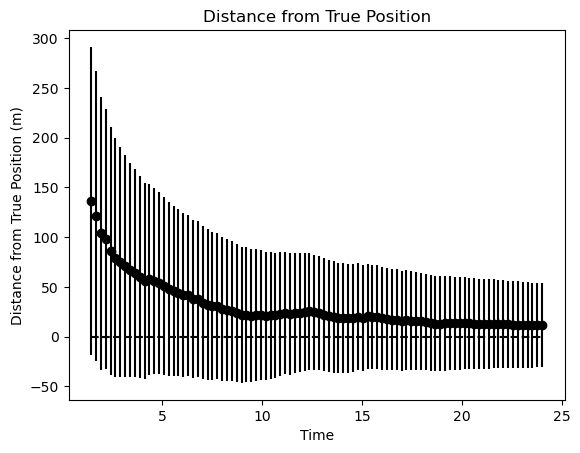

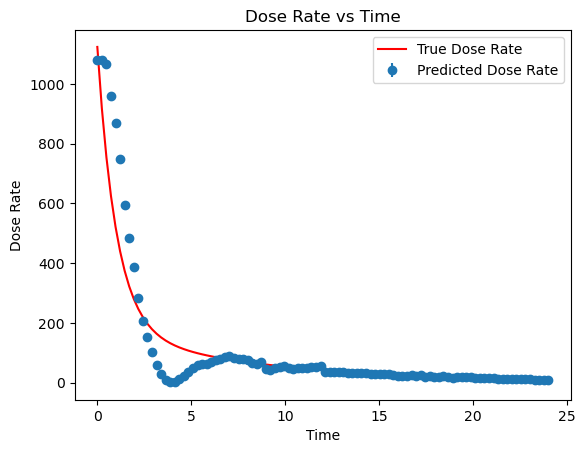

In [11]:
##confirm the results
randDet = np.random.randint(0, len(detectorField))
print(randDet)
detectorField[randDet].plotDistanceError(*detectorLocations[randDet])
detectorField[randDet].plotDoseRate(detectorField[randDet].trueDoseRates)

In [15]:
##loop the process to build a training library
nSimulations = len(falloutFields)
nTimesteps   = 100 #per 24 hours
nRunsPerSim  = 20
extimatedPixels = 4*SCARM_Parameters['nDetPerShell']*SCARM_Parameters['nArtyShells']

minDistFromGZ = 2  # minimum distance from ground zero [km]
maxDistFromGZ = 10 # maximum distance from ground zero [km]
pixelScale = .1

timesteps = np.linspace(0, falloutfield.shape[0], nTimesteps)

SCARM_Parameters = {'nArtyShells'        : 10, # number of artillery shells
                    'ArtyMinRange'       : 15, # minimum range of artillery [km]
                    'ArtyMaxRange'       : 40, # maximum range of artillery [km]
                    'ArtyFieldWidth'     :1.5, # width of the artillery field [km]
                    'ArtyFieldDepth'     : .2, # length of the artillery field [km]
                    'ArtyFieldRotation'  : 90, # angle of the artillery field from the fallout direction [degrees]
                    'nDetPerShell'       : 24, # number of detectors per shell
                    'DetDispersionWidth' : .2, # width of the detector dispersion [km]
                    'DetDispersionLength': .4, # length of the detector dispersion [km]
                    'nGateways'          :  4, # number of gateways
                    'GatewayMaxRange'    : 10, # maximum range of gateways [km]
                    'GatewayMinRange'    :  4, # minimum range of gateways [km]
                    'GatewayMaxExposure' : 50, # maximum exposure of gateways locations
                    'GatewayMinSeparation': 2, # minimum separation between gateways [km]
                    }

#data strucutre to hold the training data
# X = [nSimulations * nRunsPerSim, nTimesteps, nDetectors, 6] #detector data
# Y = [nSimulations, nPixelsX, nPixelsY, 4] #exponential parameters
# print estimated size
print(f'X: {nSimulations * nRunsPerSim * nTimesteps * len(detectorLocations) * 6 * 8 / 1e9} GB')
print(f'Y: {nSimulations * extimatedPixels * 4 * 8 / 1e9} GB')

X = np.zeros((nSimulations * nRunsPerSim, nTimesteps, len(detectorLocations), 6))
Y = {}

import os
falloutFields = [f for f in os.listdir(sourceDirectory) if os.path.isdir(os.path.join(sourceDirectory, f))]
#falloutFields = falloutFields[:2]

with Pool(128) as p:
  #for each DELFIC simulation:
  for i, falloutField in enumerate(falloutFields):
    #execute a number of detector scattering runs
    falloutFieldData, falloutDir = getFieldData(falloutField)
    Y[falloutField] = {}
    for j in range(nRunsPerSim):
      
      distFromGZ = np.random.uniform(minDistFromGZ, maxDistFromGZ)
      detectorLocations, gatewayLocations, detFieldCenter, artyDir = genDetectorField(falloutFieldData, pixelScale, falloutDir, SCARM_Parameters, distFromGZ)
      fitExpParams = getExpFitParams(falloutFieldData, detectorLocations, pixelScale)
      for pixel, params in fitExpParams.items():
        if pixel not in Y[falloutField]:
          Y[falloutField][pixel] = []
        Y[falloutField][pixel].append(params)
      detectorExposures = getDetectorExposure(detectorLocations, fitExpParams, pixelScale, timesteps)
      gateways = []
      for g, gateway in enumerate(gatewayLocations):
        gateways.append(Gateway(gateway[0], gateway[1], g))

      detectorField = []
      for d, detector in enumerate(detectorLocations):
        detectorField.append(SimDetector(detector[0], detector[1], 
                                        detectorExposures[:, d], d, gateways,
                                        timesteps))
        
      detectorField = p.map(processDetector, detectorField)
      for d, detector in enumerate(detectorField):
        X[i + j*nSimulations, :, d, :5] = detector.getFeatures(nTimesteps).T
        X[i + j*nSimulations, :, d, 5] = detector.id

##save the data
np.save('../data/X.npy', X)
np.save('../data/Y.npy', Y)

X: 0.004608 GB
Y: 6.144e-05 GB


/tmp/ipykernel_1463708/3094044384.py:21: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * t) + c * np.exp(-d * t)
/tmp/ipykernel_1463708/3094044384.py:21: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(-b * t) + c * np.exp(-d * t)
/home/dave/SCRAM/DELFIC_processing/SCRAM_field.py:85: RuntimeWarning: invalid value encountered in sqrt
  self.estimatedDoseRateUncertainties[self.updateIdx] = np.sqrt(self.doseRateFilter.P[0,0])
/home/dave/SCRAM/DELFIC_processing/SCRAM_field.py:85: RuntimeWarning: invalid value encountered in sqrt
  self.estimatedDoseRateUncertainties[self.updateIdx] = np.sqrt(self.doseRateFilter.P[0,0])
/home/dave/SCRAM/DELFIC_processing/SCRAM_field.py:85: RuntimeWarning: invalid value encountered in sqrt
  self.estimatedDoseRateUncertainties[self.updateIdx] = np.sqrt(self.doseRateFilter.P[0,0])
/home/dave/SCRAM/DELFIC_processing/SCRAM_field.py:85: RuntimeWarning: invalid value encountered in sqrt
  self.estimatedDoseRateUncertainti